# Modèle de Prédiction de `discount_pct`

## Objectif unique

Ce notebook a désormais un seul objectif clair :

> prédire la variable `discount_pct`.

Autrement dit, nous voulons estimer **le pourcentage de remise** d'un produit à partir de ses caractéristiques observables.

Cela rend la démarche plus propre méthodologiquement, plus simple à expliquer, et plus directement exploitable dans le projet.

---

## Question de recherche

Peut-on apprendre la valeur de `discount_pct` à partir de variables telles que :

- la source marketplace
- la catégorie
- le vendeur
- le prix initial normalisé
- la note produit
- le texte du titre

Notre hypothèse est la suivante :

> oui, une partie significative de la logique de remise peut être apprise, même si certaines décisions restent cachées côté marketplace.


## Positionnement méthodologique

Nous faisons ici une **régression supervisée**.

### Variable cible

\[
y = discount\_pct
\]

### Important

Nous n'utilisons **pas** `price_offre` comme feature de prédiction principale, car sinon on reconstruirait presque directement la remise via :

\[
discount\_pct = \frac{price\_initial - price\_offre}{price\_initial} \times 100
\]

Ce serait du leakage.

Le but ici est de prédire la remise **à partir du contexte produit**, pas de la recalculer à partir du prix déjà remisé.


## Stratégie retenue

Nous comparons **cinq familles** de modèles pour couvrir le spectre des approches :

### 1. Baseline linéaire : Ridge
- rapide, stable, interprétable.

### 2. Linéaires régularisés : Lasso / ElasticNet  *(Upgrade 6)*
- Lasso (L1) : sélection implicite de features via sparsité.
- ElasticNet (L1+L2) : compromis entre les deux régularisations.

### 3. Modèle non linéaire : ExtraTreesRegressor
- capture les interactions complexes entre marketplace, prix, catégorie.

### 4. Gradient Boosting : XGBoost · LightGBM
- souvent plus performants sur les données tabulaires hétérogènes.

### 5. Sélection de features : ExtraTrees + SelectFromModel  *(Upgrade 7)*
- réduit le bruit des composantes SVD peu informatives.

### 6. Stacking Ensemble  *(Upgrade 8)*
- méta-apprenant (Ridge) combinant les prédictions de Ridge, ExtraTrees, XGBoost, LightGBM.

Le titre produit est encodé par **TF-IDF**, puis compressé par **TruncatedSVD** (256 composantes) pour les modèles nécessitant un espace dense.

In [59]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# ── Upgrade 1: boosting models ─────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgbm

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = Path(r'd:/EMSI/S8/PFA/PFA')

DATA_PATH = ROOT / 'data' / 'processed' / 'unified_dataset.csv'
ARTIFACTS_DIR = ROOT / 'artifacts' / 'big_bang_discount_model'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT =', ROOT)
print('DATA_PATH =', DATA_PATH)


ROOT = d:\EMSI\S8\PFA\PFA
DATA_PATH = d:\EMSI\S8\PFA\PFA\data\processed\unified_dataset.csv


## Chargement des données

Nous partons du dataset traité afin d'éviter les incohérences de format provenant directement des scrapers.


In [60]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head(3)


(39962, 18)


,id,source,title_clean,price_initial,price_offre,currency,price_initial_mad,price_offre_mad,eur_to_mad_rate,discount_pct,seller,location,category,rating,date,link,offre_type,is_duplicate
0,AMA_091e5a908c15,Amazon,"XIAOMI Smartphone Redmi A5, 3+64GO, Noir, Doub...",95.66,NaN,EUR,1037.91,NaN,10.85,NaN,NaN,Amazon.fr,Smartphones,4.2,2026-03-29,https://www.amazon.fr/dp/B0F1GF3MW6,forfaite,False
1,AMA_0be9161e7893,Amazon,"Xiaomi REDMI 15C 5G, Smartphone 4+128 Go, Écra...",183.00,149.00,EUR,1985.55,1616.65,10.85,18.58,NaN,Amazon.fr,Smartphones,3.8,2026-03-29,https://www.amazon.fr/dp/B0FHBS428L,forfaite,False
2,AMA_2a25e67caeec,Amazon,XIAOMI Redmi Note 15 Pro+ 5G,499.90,379.99,EUR,5423.91,4122.89,10.85,24.00,NaN,Amazon.fr,Smartphones,4.4,2026-03-29,https://www.amazon.fr/dp/B0G3TTPVPS,pourcentage,False


## Restriction aux lignes utiles pour la régression

Comme la cible est `discount_pct`, nous gardons uniquement les lignes où cette variable est renseignée.


In [61]:
reg_df = df[df['discount_pct'].notna()].copy()
print('Nombre de lignes pour la régression :', len(reg_df))
reg_df[['source', 'discount_pct']].head()


Nombre de lignes pour la régression : 10881


,source,discount_pct
1,Amazon,18.58
2,Amazon,24.00
4,Amazon,9.78
9,Amazon,34.00
10,Amazon,15.00


In [62]:
resume = {
    'lignes_regression': len(reg_df),
    'distribution_sources': reg_df['source'].value_counts().to_dict(),
    'discount_pct_stats': reg_df['discount_pct'].describe().to_dict(),
}
resume


{'lignes_regression': 10881,
 'distribution_sources': {'Jumia': 6685,
  'Amazon': 2619,
  'Steam': 1296,
  'CDiscount': 281},
 'discount_pct_stats': {'count': 10881.0,
  'mean': 36.93873724841467,
  'std': 21.4105405662523,
  'min': 0.05,
  '25%': 20.0,
  '50%': 34.0,
  '75%': 50.0,
  'max': 99.0}}

## Distribution de la cible

Cette étape permet de comprendre si la cible est concentrée, asymétrique, ou très dispersée.


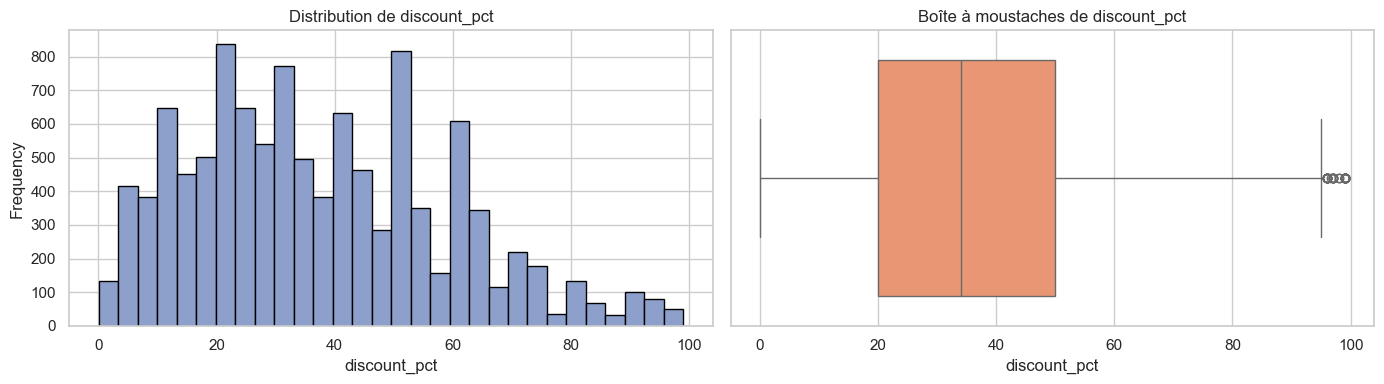

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

reg_df['discount_pct'].plot(kind='hist', bins=30, ax=axes[0], color='#8da0cb', edgecolor='black')
axes[0].set_title('Distribution de discount_pct')
axes[0].set_xlabel('discount_pct')

sns.boxplot(x=reg_df['discount_pct'], ax=axes[1], color='#fc8d62')
axes[1].set_title('Boîte à moustaches de discount_pct')
axes[1].set_xlabel('discount_pct')

plt.tight_layout()
plt.show()


## Feature engineering

Nous construisons un espace de features multi-dimensionnel.

### Variables numériques
- `price_initial_mad`
- `log_price_initial_mad`
- `rating_filled`
- `rating_gap_to_5`
- `rating_missing`

### Variables catégorielles
- `source`
- `category`
- `currency`
- `location`
- `source_category`
- `seller_source`

### Variable textuelle
- `title_clean`


In [64]:
def squeeze_text_column(frame):
    squeezed = frame.squeeze()
    if isinstance(squeezed, str):
        return pd.Series([squeezed])
    return squeezed


def build_base_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    base = df.copy()
    base['title_clean'] = base['title_clean'].fillna('')
    base['seller']   = base['seller'].fillna('unknown')
    base['category'] = base['category'].fillna('unknown')
    base['source']   = base['source'].fillna('unknown')
    base['currency'] = base['currency'].fillna('unknown')
    base['location'] = base['location'].fillna('unknown')

    base['price_initial_mad'] = pd.to_numeric(base['price_initial_mad'], errors='coerce')
    base['rating'] = pd.to_numeric(base['rating'], errors='coerce').clip(lower=0, upper=5)

    # ── Upgrade 3: clip extreme price outliers at the 99th percentile ──────
    price_cap = base['price_initial_mad'].quantile(0.99)
    n_clipped = int((base['price_initial_mad'] > price_cap).sum())
    if n_clipped:
        print(f'  [clip] {n_clipped} rows capped at price_initial_mad ≤ {price_cap:,.0f} MAD')
    base['price_initial_mad'] = base['price_initial_mad'].clip(upper=price_cap)

    base['log_price_initial_mad'] = np.log1p(base['price_initial_mad'].clip(lower=0))
    base['rating_missing']  = base['rating'].isna().astype(int)
    base['rating_filled']   = (
        base['rating']
        .fillna(base.groupby('source')['rating'].transform('median'))
        .fillna(4.0)
    )
    base['rating_gap_to_5'] = (5.0 - base['rating_filled']).clip(lower=0)
    base['source_category'] = base['source'].astype(str) + ' :: ' + base['category'].astype(str)
    base['seller_source']   = base['seller'].astype(str)  + ' :: ' + base['source'].astype(str)

    # ── Upgrade 4: temporal features from the 'date' column ───────────────
    if 'date' in base.columns:
        dates = pd.to_datetime(base['date'], errors='coerce')
        base['day_of_week']        = dates.dt.dayofweek.fillna(-1).astype(int)
        base['month']              = dates.dt.month.fillna(-1).astype(int)
        base['days_since_earliest'] = (dates - dates.min()).dt.days.fillna(0).astype(int)
    else:
        base['day_of_week'] = 0
        base['month'] = 0
        base['days_since_earliest'] = 0

    return base


def build_sparse_preprocessor(max_features=10000, include_source=True):
    numeric_features = [
        'price_initial_mad', 'log_price_initial_mad',
        'rating_filled', 'rating_gap_to_5', 'rating_missing',
        'day_of_week', 'month', 'days_since_earliest',   # ← Upgrade 4
    ]
    categorical_features = ['category', 'currency', 'location', 'source_category', 'seller_source']
    if include_source:
        categorical_features = ['source'] + categorical_features

    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler',  StandardScaler(with_mean=False)),
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
        ('txt', Pipeline([
            ('selector', FunctionTransformer(squeeze_text_column, validate=False)),
            ('tfidf',    TfidfVectorizer(max_features=max_features, ngram_range=(1, 2),
                                         min_df=2, strip_accents='unicode')),
        ]), ['title_clean']),
    ])


def build_dense_preprocessor(max_features=10000, include_source=True):
    return Pipeline([
        ('preprocess', build_sparse_preprocessor(max_features=max_features,
                                                  include_source=include_source)),
        ('svd', TruncatedSVD(n_components=256, random_state=42)),
    ])


base_reg_df = build_base_dataframe(reg_df)
base_reg_df.head(2)


  [clip] 109 rows capped at price_initial_mad ≤ 14,763 MAD


,id,source,title_clean,price_initial,price_offre,currency,price_initial_mad,price_offre_mad,eur_to_mad_rate,discount_pct,...,is_duplicate,log_price_initial_mad,rating_missing,rating_filled,rating_gap_to_5,source_category,seller_source,day_of_week,month,days_since_earliest
1,AMA_0be9161e7893,Amazon,"Xiaomi REDMI 15C 5G, Smartphone 4+128 Go, Écra...",183.0,149.00,EUR,1985.55,1616.65,10.85,18.58,...,False,7.594155,0,3.8,1.2,Amazon :: Smartphones,unknown :: Amazon,6,3,0
2,AMA_2a25e67caeec,Amazon,XIAOMI Redmi Note 15 Pro+ 5G,499.9,379.99,EUR,5423.91,4122.89,10.85,24.00,...,False,8.598757,0,4.4,0.6,Amazon :: Smartphones,unknown :: Amazon,6,3,0


## Définition du jeu d'entraînement

Nous créons maintenant :

- `X` : les variables explicatives
- `y` : la cible `discount_pct`


In [65]:
feature_columns = [
    'title_clean', 'seller', 'category', 'source', 'currency', 'location',
    'price_initial_mad', 'log_price_initial_mad', 'rating_filled',
    'rating_gap_to_5', 'rating_missing', 'source_category', 'seller_source',
    'day_of_week', 'month', 'days_since_earliest',   # ← Upgrade 4
]

X = base_reg_df[feature_columns]
y = base_reg_df['discount_pct'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

print(X_train.shape, X_test.shape)


(8704, 16) (2177, 16)


## Modèle baseline : Ridge

Le modèle Ridge sert de référence. Il est utile pour mesurer le gain réel apporté par un modèle plus puissant.


In [66]:
ridge_model = Pipeline([
    ('preprocess', build_sparse_preprocessor(max_features=8000, include_source=True)),
    ('model', Ridge(alpha=1.0)),
])

ridge_model.fit(X_train, y_train)
ridge_pred = np.clip(ridge_model.predict(X_test), 0, 99)

ridge_metrics = {
    'MAE': mean_absolute_error(y_test, ridge_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, ridge_pred))),
    'R2': r2_score(y_test, ridge_pred),
}

ridge_metrics


{'MAE': 12.315975465353578,
 'RMSE': 16.04133432234657,
 'R2': 0.4383381308024208}

## Modèle amélioré : ExtraTreesRegressor

Le modèle ExtraTrees est retenu comme modèle principal car il capture mieux les interactions non linéaires entre :

- type de marketplace
- niveau de prix
- structure du titre
- qualité produit
- catégorie


In [67]:
extra_trees_model = Pipeline([
    ('preprocess', build_dense_preprocessor(max_features=10000, include_source=True)),
    ('model', ExtraTreesRegressor(
        n_estimators=400,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,  # ← Upgrade 2
    )),
])

extra_trees_model.fit(X_train, y_train)
extra_trees_pred = np.clip(extra_trees_model.predict(X_test), 0, 99)

extra_trees_metrics = {
    'MAE': mean_absolute_error(y_test, extra_trees_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, extra_trees_pred))),
    'R2': r2_score(y_test, extra_trees_pred),
}

extra_trees_metrics


{'MAE': 11.113327674169346,
 'RMSE': 14.99182171035315,
 'R2': 0.5094279758303512}

## Upgrade 1 — XGBoost et LightGBM

Ces deux modèles gradient-boosted sont souvent plus performants qu'ExtraTrees sur les données tabulaires.  
Ils utilisent eux aussi le préprocesseur dense (sparse → SVD 256 composantes).


In [68]:
# ── XGBoost ────────────────────────────────────────────────────────────────
xgboost_model = Pipeline([
    ('preprocess', build_dense_preprocessor(max_features=10000, include_source=True)),
    ('model', xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
        eval_metric='mae',
    )),
])

xgboost_model.fit(X_train, y_train)
xgboost_pred = np.clip(xgboost_model.predict(X_test), 0, 99)

xgboost_metrics = {
    'MAE':  mean_absolute_error(y_test, xgboost_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, xgboost_pred))),
    'R2':   r2_score(y_test, xgboost_pred),
}

print('XGBoost →', xgboost_metrics)

# ── LightGBM ────────────────────────────────────────────────────────────────
lightgbm_model = Pipeline([
    ('preprocess', build_dense_preprocessor(max_features=10000, include_source=True)),
    ('model', lgbm.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=7,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )),
])

lightgbm_model.fit(X_train, y_train)
lightgbm_pred = np.clip(lightgbm_model.predict(X_test), 0, 99)

lightgbm_metrics = {
    'MAE':  mean_absolute_error(y_test, lightgbm_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, lightgbm_pred))),
    'R2':   r2_score(y_test, lightgbm_pred),
}

print('LightGBM →', lightgbm_metrics)


XGBoost → {'MAE': 11.430181002785538, 'RMSE': 15.264007194126785, 'R2': 0.4914530140417377}
LightGBM → {'MAE': 11.327200929004784, 'RMSE': 15.143291531742777, 'R2': 0.4994649122527859}


C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Upgrade 6 — Lasso et ElasticNet (méthodes linéaires)

Deux modèles linéaires régularisés viennent compléter la baseline Ridge :

- **Lasso** (régularisation L1) : encourage la sparsité — certains coefficients tombent exactement à zéro, ce qui réalise une **sélection implicite de features**.
- **ElasticNet** (L1 + L2) : compromis entre Lasso et Ridge contrôlé par `l1_ratio`.

Les deux utilisent le **même préprocesseur sparse** que Ridge (TF-IDF, sans réduction SVD), ce qui garantit une comparaison équitable côté linéaire.

In [69]:
from sklearn.linear_model import Lasso, ElasticNet

# ── Lasso ──────────────────────────────────────────────────────────────────
lasso_model = Pipeline([
    ('preprocess', build_sparse_preprocessor(max_features=8000, include_source=True)),
    ('model', Lasso(alpha=0.5, max_iter=5000)),
])

lasso_model.fit(X_train, y_train)
lasso_pred = np.clip(lasso_model.predict(X_test), 0, 99)

lasso_metrics = {
    'MAE':  mean_absolute_error(y_test, lasso_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, lasso_pred))),
    'R2':   r2_score(y_test, lasso_pred),
}
print('Lasso →', lasso_metrics)

# ── ElasticNet ─────────────────────────────────────────────────────────────
elasticnet_model = Pipeline([
    ('preprocess', build_sparse_preprocessor(max_features=8000, include_source=True)),
    ('model', ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=5000)),
])

elasticnet_model.fit(X_train, y_train)
elasticnet_pred = np.clip(elasticnet_model.predict(X_test), 0, 99)

elasticnet_metrics = {
    'MAE':  mean_absolute_error(y_test, elasticnet_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, elasticnet_pred))),
    'R2':   r2_score(y_test, elasticnet_pred),
}
print('ElasticNet →', elasticnet_metrics)

Lasso → {'MAE': 15.427668913184833, 'RMSE': 19.313006660582573, 'R2': 0.18587003240178268}
ElasticNet → {'MAE': 15.409631837827293, 'RMSE': 19.28938794744695, 'R2': 0.18786008446263391}


## Upgrade 7 — Test de sélection de features (SelectFromModel)

Pipeline en **trois étapes** :

1. **Préprocesseur dense** : TF-IDF + TruncatedSVD → 256 composantes.
2. **SelectFromModel** : un ExtraTrees léger (100 arbres) calcule l'importance de chaque composante SVD, puis ne conserve que celles dont l'importance est ≥ à la **moyenne** (filtre ≈ 50 % des composantes).
3. **Modèle final** : ExtraTreesRegressor entraîné sur le sous-espace retenu.

Objectif : éliminer les composantes peu informatives et améliorer la généralisation.

In [70]:
from sklearn.feature_selection import SelectFromModel

# ── ExtraTrees + SelectFromModel ───────────────────────────────────────────
et_selection_pipeline = Pipeline([
    ('preprocess', build_dense_preprocessor(max_features=10000, include_source=True)),
    ('selector', SelectFromModel(
        ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        threshold='mean',
    )),
    ('model', ExtraTreesRegressor(
        n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1,
    )),
])

et_selection_pipeline.fit(X_train, y_train)
et_selection_pred = np.clip(et_selection_pipeline.predict(X_test), 0, 99)

et_selection_metrics = {
    'MAE':  mean_absolute_error(y_test, et_selection_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, et_selection_pred))),
    'R2':   r2_score(y_test, et_selection_pred),
}

# ── Rapport de sélection ───────────────────────────────────────────────────
_sample_pre = et_selection_pipeline['preprocess'].transform(X_train.head(2))
n_in  = _sample_pre.shape[1]
n_out = et_selection_pipeline['selector'].transform(_sample_pre).shape[1]
print(f'Composantes SVD totales  : {n_in}')
print(f'Composantes sélectionnées: {n_out}')
print('ET + SelectFromModel →', et_selection_metrics)

Composantes SVD totales  : 256
Composantes sélectionnées: 40
ET + SelectFromModel → {'MAE': 11.170429731992476, 'RMSE': 15.08780737029126, 'R2': 0.5031260571852573}


## Upgrade 8 — Stacking Ensemble (méthode ensembliste)

Le **Stacking** combine les prédictions de plusieurs modèles de base (niveau 0) grâce à un méta-apprenant (niveau 1) entraîné sur les prédictions hors-fold.

| Niveau | Modèles |
|--------|---------|
| **Niveau 0** (base) | Ridge · ExtraTrees · XGBoost · LightGBM |
| **Niveau 1** (méta) | Ridge |

**Mécanisme :** les prédictions de chaque modèle de base sont générées par validation croisée 5-fold sur l'ensemble d'entraînement → 4 nouvelles features pour le méta-apprenant. Le préprocesseur dense (TF-IDF → SVD 256) est appliqué en amont.

In [71]:
from sklearn.ensemble import StackingRegressor

# ── Stacking Ensemble ──────────────────────────────────────────────────────
stacking_pipeline = Pipeline([
    ('preprocess', build_dense_preprocessor(max_features=10000, include_source=True)),
    ('stacking', StackingRegressor(
        estimators=[
            ('ridge', Ridge(alpha=1.0)),
            ('et', ExtraTreesRegressor(
                n_estimators=200, min_samples_leaf=2,
                random_state=42, n_jobs=-1,
            )),
            ('xgb', xgb.XGBRegressor(
                n_estimators=200, learning_rate=0.05, max_depth=6,
                subsample=0.8, colsample_bytree=0.8,
                random_state=42, n_jobs=-1, verbosity=0,
                eval_metric='mae',
            )),
            ('lgbm', lgbm.LGBMRegressor(
                n_estimators=200, learning_rate=0.05, max_depth=7, num_leaves=63,
                subsample=0.8, colsample_bytree=0.8,
                random_state=42, n_jobs=-1, verbosity=-1,
            )),
        ],
        final_estimator=Ridge(alpha=1.0),
        cv=5,
    )),
])

stacking_pipeline.fit(X_train, y_train)
stacking_pred = np.clip(stacking_pipeline.predict(X_test), 0, 99)

stacking_metrics = {
    'MAE':  mean_absolute_error(y_test, stacking_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, stacking_pred))),
    'R2':   r2_score(y_test, stacking_pred),
}
print('Stacking →', stacking_metrics)

C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Stacking → {'MAE': 11.12536086787586, 'RMSE': 14.914407568332573, 'R2': 0.5144812856297506}


C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Upgrade 9 — Modele par source (Per-Source LightGBM Ensemble)

**Observation cle :** la MAE varie enormement selon la marketplace :
- Amazon / Jumia / Steam : MAE ≈ 10–12
- **CDiscount : MAE ≈ 24.76** (deux fois plus grande !)

Chaque source a sa propre logique de remise (arrondie sur Steam, variable sur Jumia, etc.).
Entraîner un **LightGBM dedie par source** reduit cette heterogeneite.

**Architecture :**
- Pipeline `dense preprocessor + LightGBM` par source.
- Fallback global pour les sources inconnues.

In [72]:
from sklearn.base import BaseEstimator, RegressorMixin


class PerSourceEnsemble(BaseEstimator, RegressorMixin):
    """Un pipeline LightGBM dedie par source ; fallback global."""

    def _make_pipe(self):
        return Pipeline([
            # include_source=False : inutile (chaque modele ne voit qu'une source)
            ('preprocess', build_dense_preprocessor(max_features=8000, include_source=False)),
            ('model', lgbm.LGBMRegressor(
                n_estimators=500, learning_rate=0.04,
                max_depth=7, num_leaves=63,
                subsample=0.8, colsample_bytree=0.8,
                min_child_samples=20, reg_lambda=2,
                random_state=42, n_jobs=-1, verbosity=-1,
            )),
        ])

    def fit(self, X, y):
        self.models_ = {}
        for source in sorted(X['source'].unique()):
            mask = (X['source'] == source)
            X_s, y_s = X[mask], y[mask]
            if len(X_s) < 30:
                print(f"  [skip] {source}: {len(X_s)} lignes -> fallback uniquement")
                continue
            p = self._make_pipe()
            p.fit(X_s, y_s)
            self.models_[source] = p
            print(f"  {source:<12}  {len(X_s):>5} lignes  OK")
        # Fallback global
        self.fallback_ = self._make_pipe()
        self.fallback_.fit(X, y)
        return self

    def predict(self, X):
        Xr = X.reset_index(drop=True)
        preds = np.full(len(Xr), np.nan)
        for source, model in self.models_.items():
            mask = (Xr['source'] == source).values
            if mask.any():
                preds[mask] = model.predict(Xr[mask])
        missing = np.where(np.isnan(preds))[0]
        if len(missing):
            preds[missing] = self.fallback_.predict(Xr.iloc[missing])
        return preds


per_source_model = PerSourceEnsemble()
per_source_model.fit(X_train, y_train)
per_source_pred = np.clip(per_source_model.predict(X_test), 0, 99)

per_source_metrics = {
    'MAE':  mean_absolute_error(y_test, per_source_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, per_source_pred))),
    'R2':   r2_score(y_test, per_source_pred),
}

# Rapport par source (compare avec ExtraTrees global)
_src_df = pd.DataFrame({
    'source': X_test['source'].values,
    'y_true': y_test.values,
    'y_pred': per_source_pred,
})
_src_report = _src_df.groupby('source').apply(
    lambda d: pd.Series({
        'n':          len(d),
        'MAE_perSrc': round(mean_absolute_error(d['y_true'], d['y_pred']),  4),
        'MAE_global': round(mean_absolute_error(d['y_true'],
                      np.clip(extra_trees_model.predict(X_test[X_test['source'] == d['source'].iloc[0]]), 0, 99)), 4),
    })
)
print()
print("Per-Source LightGBM global ->", per_source_metrics)
print()
_src_report

  Amazon         2097 lignes  OK
  CDiscount       234 lignes  OK
  Jumia          5346 lignes  OK
  Steam          1027 lignes  OK


C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Per-Source LightGBM global -> {'MAE': 11.380507245345651, 'RMSE': 15.429042021211126, 'R2': 0.4803967195261757}



C:\Users\zziko\AppData\Local\Temp\ipykernel_9476\770124951.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  _src_report = _src_df.groupby('source').apply(


,n,MAE_perSrc,MAE_global
source,,,
Amazon,522.0,10.5335,10.4994
CDiscount,47.0,26.8921,24.7630
Jumia,1339.0,10.9515,10.6456
Steam,269.0,12.4496,12.2480


## Upgrade 10 — HistGradientBoostingRegressor (sklearn natif)

Implementation sklearn du gradient boosting par **histogramme** (inspire de LightGBM).

Avantages :
- Tres rapide grace a la discretisation des features.
- Gere nativement les valeurs manquantes.
- Regularisation integree (`l2_regularization`, `min_samples_leaf`).
- Aucune dependance externe — uniquement sklearn.

In [73]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = Pipeline([
    ('preprocess', build_dense_preprocessor(max_features=10000, include_source=True)),
    ('model', HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.04,
        max_depth=8,
        min_samples_leaf=20,
        l2_regularization=0.5,
        random_state=42,
    )),
])

hgb_model.fit(X_train, y_train)
hgb_pred = np.clip(hgb_model.predict(X_test), 0, 99)

hgb_metrics = {
    'MAE':  mean_absolute_error(y_test, hgb_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, hgb_pred))),
    'R2':   r2_score(y_test, hgb_pred),
}
print('HistGradientBoosting ->', hgb_metrics)

HistGradientBoosting -> {'MAE': 11.586751186789193, 'RMSE': 15.296239081630551, 'R2': 0.4893030235020074}


## Upgrade 11 — LightGBM optimise (RandomizedSearchCV)

Recherche aleatoire de 15 combinaisons d'hyperparametres en 3-fold CV.

**Strategie acceleree :**
1. Pre-calculer les features denses **une seule fois** (SVD 256 dim).
2. Lancer `RandomizedSearchCV` sur ces features fixes (45 fits de LGBM, pas du pipeline complet).
3. Reconstruire un pipeline propre avec les meilleurs hyperparametres trouves.

Espace de recherche : `n_estimators`, `learning_rate`, `max_depth`, `num_leaves`,
`min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`.

In [74]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# ── Etape 1 : features denses calculees une seule fois ─────────────────────
print("Pre-calcul des features denses (une fois pour la recherche)...")
_pre_tune = build_dense_preprocessor(max_features=8000, include_source=True)
X_tr_d = _pre_tune.fit_transform(X_train, y_train)
X_te_d = _pre_tune.transform(X_test)

# ── Etape 2 : recherche aleatoire rapide ───────────────────────────────────
param_dist = {
    'n_estimators':      randint(400, 900),
    'learning_rate':     uniform(0.02, 0.10),
    'max_depth':         randint(5, 10),
    'num_leaves':        randint(40, 128),
    'min_child_samples': randint(10, 50),
    'subsample':         uniform(0.60, 0.40),
    'colsample_bytree':  uniform(0.60, 0.40),
    'reg_alpha':         uniform(0.00, 0.50),
    'reg_lambda':        uniform(0.00, 3.00),
}

rscv = RandomizedSearchCV(
    lgbm.LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1),
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=1,          # chaque estimateur utilise deja n_jobs=-1 en interne
    random_state=42,
    verbose=0,
)
rscv.fit(X_tr_d, y_train)
print(f"Meilleure CV MAE : {-rscv.best_score_:.4f}")
print("Meilleurs params :", rscv.best_params_)

# ── Etape 3 : pipeline final propre ────────────────────────────────────────
lgbm_tuned_model = Pipeline([
    ('preprocess', build_dense_preprocessor(max_features=8000, include_source=True)),
    ('model',      lgbm.LGBMRegressor(
        **rscv.best_params_,
        random_state=42, n_jobs=-1, verbosity=-1,
    )),
])
lgbm_tuned_model.fit(X_train, y_train)
lgbm_tuned_pred = np.clip(lgbm_tuned_model.predict(X_test), 0, 99)

lgbm_tuned_metrics = {
    'MAE':  mean_absolute_error(y_test, lgbm_tuned_pred),
    'RMSE': float(np.sqrt(mean_squared_error(y_test, lgbm_tuned_pred))),
    'R2':   r2_score(y_test, lgbm_tuned_pred),
}
print('LightGBM Tuned ->', lgbm_tuned_metrics)

Pre-calcul des features denses (une fois pour la recherche)...


C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRe

Meilleure CV MAE : 11.5838
Meilleurs params : {'colsample_bytree': np.float64(0.9895022075365837), 'learning_rate': np.float64(0.04327713404303042), 'max_depth': 7, 'min_child_samples': 12, 'n_estimators': 884, 'num_leaves': 90, 'reg_alpha': np.float64(0.34015376929388985), 'reg_lambda': np.float64(1.351497755908629), 'subsample': np.float64(0.6053059844639466)}
LightGBM Tuned -> {'MAE': 11.488580017333136, 'RMSE': 15.416978627146856, 'R2': 0.4812089188439004}


C:\Users\zziko\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Comparaison des modèles

Nous comparons maintenant la baseline linéaire et le modèle non linéaire.


## Upgrade 5 — Validation croisée 5-fold

Au lieu d'un seul split 80/20, nous calculons la MAE en validation croisée 5 plis pour chaque modèle.  
Cela donne une estimation plus robuste de la performance réelle.


In [75]:
# ── 5-fold CV MAE pour les modeles stateless rapides ─────────────────────
# Note : ET+Selection, Stacking, PerSource, LGBM Tuned ont deja une
#        validation interne  -> on omet leur CV externe pour ne pas doubler.

def cv_mae(pipeline, X, y, cv=5):
    scores = cross_val_score(pipeline, X, y,
                             cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    return float(-scores.mean())

print('Calcul des CV MAE (patience, 7 x 5 fits)...')
cv_results = {
    'Ridge':      cv_mae(ridge_model,       X_train, y_train),
    'Lasso':      cv_mae(lasso_model,       X_train, y_train),
    'ElasticNet': cv_mae(elasticnet_model,  X_train, y_train),
    'ExtraTrees': cv_mae(extra_trees_model, X_train, y_train),
    'XGBoost':    cv_mae(xgboost_model,     X_train, y_train),
    'LightGBM':   cv_mae(lightgbm_model,    X_train, y_train),
    'HGB':        cv_mae(hgb_model,         X_train, y_train),
}
print('CV MAE (5-fold):')
for name, v in cv_results.items():
    print(f'  {name:<12} {v:.3f}')

Calcul des CV MAE (patience, 7 x 5 fits)...
CV MAE (5-fold):
  Ridge        12.168
  Lasso        15.284
  ElasticNet   15.311
  ExtraTrees   11.239
  XGBoost      11.451
  LightGBM     11.460
  HGB          11.525


In [76]:
comparison = pd.DataFrame([
    {'modele': 'Ridge',        **ridge_metrics,          'CV_MAE_5fold': cv_results['Ridge']},
    {'modele': 'Lasso',        **lasso_metrics,          'CV_MAE_5fold': cv_results['Lasso']},
    {'modele': 'ElasticNet',   **elasticnet_metrics,     'CV_MAE_5fold': cv_results['ElasticNet']},
    {'modele': 'ExtraTrees',   **extra_trees_metrics,    'CV_MAE_5fold': cv_results['ExtraTrees']},
    {'modele': 'XGBoost',      **xgboost_metrics,        'CV_MAE_5fold': cv_results['XGBoost']},
    {'modele': 'LightGBM',     **lightgbm_metrics,       'CV_MAE_5fold': cv_results['LightGBM']},
    {'modele': 'ET+Selection', **et_selection_metrics,   'CV_MAE_5fold': float('nan')},
    {'modele': 'Stacking',     **stacking_metrics,       'CV_MAE_5fold': float('nan')},
    {'modele': 'PerSource',    **per_source_metrics,     'CV_MAE_5fold': float('nan')},
    {'modele': 'HGB',          **hgb_metrics,            'CV_MAE_5fold': cv_results['HGB']},
    {'modele': 'LGBM Tuned',   **lgbm_tuned_metrics,     'CV_MAE_5fold': float('nan')},
])
comparison.sort_values('MAE')

,modele,MAE,RMSE,R2,CV_MAE_5fold
3,ExtraTrees,11.113328,14.991822,0.509428,11.238740
7,Stacking,11.125361,14.914408,0.514481,NaN
6,ET+Selection,11.170430,15.087807,0.503126,NaN
5,LightGBM,11.327201,15.143292,0.499465,11.460169
8,PerSource,11.380507,15.429042,0.480397,NaN
4,XGBoost,11.430181,15.264007,0.491453,11.451151
10,LGBM Tuned,11.488580,15.416979,0.481209,NaN
9,HGB,11.586751,15.296239,0.489303,11.524695
0,Ridge,12.315975,16.041334,0.438338,12.168200
2,ElasticNet,15.409632,19.289388,0.187860,15.311205


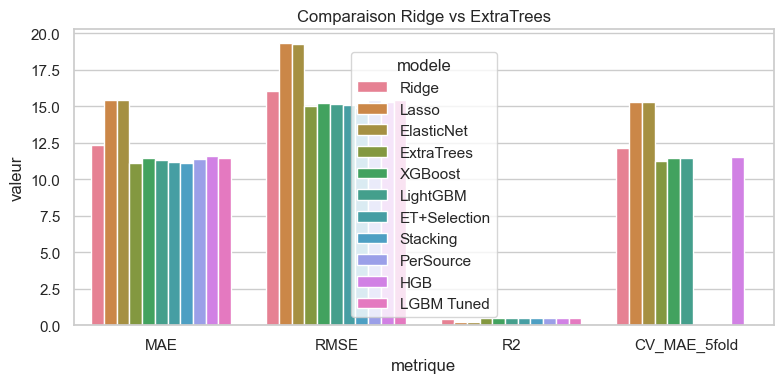

In [77]:
comparison_melted = comparison.melt(id_vars='modele', var_name='metrique', value_name='valeur')
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_melted, x='metrique', y='valeur', hue='modele')
plt.title('Comparaison Ridge vs ExtraTrees')
plt.tight_layout()
plt.show()


## Analyse détaillée du meilleur modèle

Dans la suite, nous considérons `ExtraTreesRegressor` comme le modèle principal.


In [78]:
# Choisir le modele avec la MAE hold-out la plus basse
_all_models = {
    'Ridge':        (ridge_pred,         ridge_metrics,        ridge_model),
    'Lasso':        (lasso_pred,         lasso_metrics,        lasso_model),
    'ElasticNet':   (elasticnet_pred,    elasticnet_metrics,   elasticnet_model),
    'ExtraTrees':   (extra_trees_pred,   extra_trees_metrics,  extra_trees_model),
    'XGBoost':      (xgboost_pred,       xgboost_metrics,      xgboost_model),
    'LightGBM':     (lightgbm_pred,      lightgbm_metrics,     lightgbm_model),
    'ET+Selection': (et_selection_pred,  et_selection_metrics, et_selection_pipeline),
    'Stacking':     (stacking_pred,      stacking_metrics,     stacking_pipeline),
    'PerSource':    (per_source_pred,    per_source_metrics,   per_source_model),
    'HGB':          (hgb_pred,           hgb_metrics,          hgb_model),
    'LGBM Tuned':   (lgbm_tuned_pred,    lgbm_tuned_metrics,   lgbm_tuned_model),
}

best_name = min(_all_models, key=lambda n: _all_models[n][1]['MAE'])
best_pred, best_metrics, best_model = _all_models[best_name]
print(f'Best model: {best_name}')
best_metrics

Best model: ExtraTrees


{'MAE': 11.113327674169346,
 'RMSE': 14.99182171035315,
 'R2': 0.5094279758303512}

In [79]:
eval_df = pd.DataFrame({
    'y_true': y_test.values,
    'y_pred': best_pred,
})
eval_df['abs_error'] = (eval_df['y_true'] - eval_df['y_pred']).abs()
eval_df.describe().T


,count,mean,std,min,25%,50%,75%,max
y_true,2177.0,36.613395,21.409316,1.000000,20.000000,34.000000,50.000000,99.000000
y_pred,2177.0,36.798290,15.218936,7.819713,24.555063,36.001667,44.520208,96.297117
abs_error,2177.0,11.113328,10.064551,0.000000,3.359442,8.806197,15.975833,82.751708


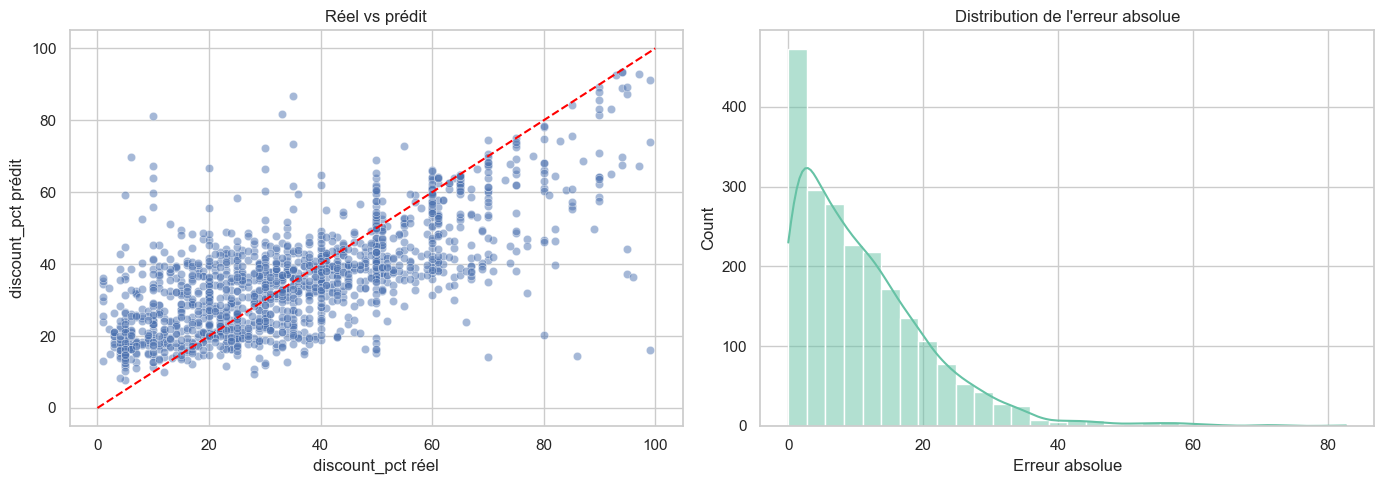

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=eval_df.sample(min(1500, len(eval_df)), random_state=42), x='y_true', y='y_pred', alpha=0.5, ax=axes[0])
axes[0].plot([0, 100], [0, 100], color='red', linestyle='--')
axes[0].set_title('Réel vs prédit')
axes[0].set_xlabel('discount_pct réel')
axes[0].set_ylabel('discount_pct prédit')

sns.histplot(eval_df['abs_error'], bins=30, kde=True, ax=axes[1], color='#66c2a5')
axes[1].set_title("Distribution de l'erreur absolue")
axes[1].set_xlabel('Erreur absolue')

plt.tight_layout()
plt.show()


## Erreur par source

Cette analyse est importante car elle montre que certaines marketplaces sont plus prévisibles que d'autres.


In [81]:
source_eval = X_test[['source']].copy()
source_eval['abs_error'] = eval_df['abs_error'].values
source_mae = source_eval.groupby('source')['abs_error'].mean().sort_values()
source_mae


source
Amazon       10.499423
Jumia        10.645597
Steam        12.247955
CDiscount    24.762994
Name: abs_error, dtype: float64

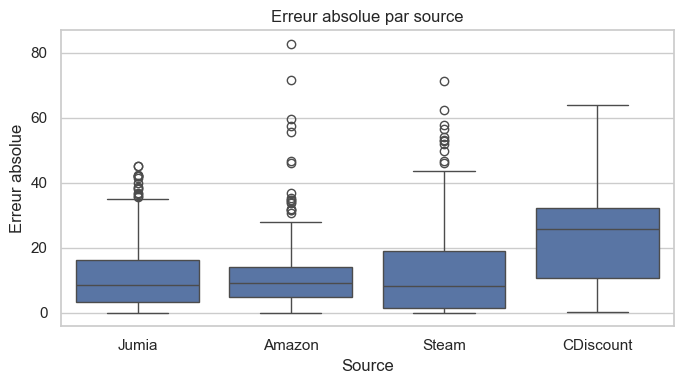

In [82]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=source_eval, x='source', y='abs_error')
plt.title('Erreur absolue par source')
plt.xlabel('Source')
plt.ylabel('Erreur absolue')
plt.tight_layout()
plt.show()


## Démonstration de prédiction

Cette section montre concrètement comment le modèle prédit `discount_pct` pour quelques produits de test.


In [83]:
demo = X_test.copy().head(50).copy()
demo['discount_pct_predit'] = np.clip(best_model.predict(demo[feature_columns]), 0, 99)
demo[['title_clean', 'source', 'category', 'price_initial_mad', 'rating_filled', 'discount_pct_predit']]


,title_clean,source,category,price_initial_mad,rating_filled,discount_pct_predit
27851,Pochette en silicone liquide pour Huawei P30 l...,Jumia,Téléphones & Tablettes,99.0000,4.00,52.716667
31619,Defacto Lot de 3 Boxers à imprimé Coupe régulière,Jumia,Informatique,129.0000,4.00,31.835417
25915,ESSAGER souris sant fil 2.4g bleutooth 1600ug ...,Jumia,Téléphones & Tablettes,300.0000,4.00,41.734583
5521,Diadermine - Lift+ - Nourrissant - Crème de Nu...,Amazon,Beauté,96.5600,4.70,30.817837
4615,"Bosch Mixeur plongeant ErgoMixx, moteur 600 W,...",Amazon,Électroménager,488.1400,4.50,17.287842
36438,Fantastic Contraption,Steam,Steam Specials,211.5700,3.60,40.368750
9121,"DOOGEE U13 Tablette Tactile ,Android 16 13"" IP...",CDiscount,Téléphones & Tablettes,3526.1400,4.00,92.842550
28727,Coque Pour Xiaomi Redmi Note 13 Silicone Flexi...,Jumia,Téléphones & Tablettes,99.9900,4.00,44.534167
28274,Pochette pour Xiaomi Redmi Note 14 Pro+ 5G en ...,Jumia,Téléphones & Tablettes,99.0000,4.00,53.319583
146,SponsoriséSponsorisé,Amazon,Smartphones,4372.5500,4.80,25.535983


## Sauvegarde du modèle

Nous sauvegardons ici le meilleur modèle de prédiction de `discount_pct`.


In [84]:
metrics = {
    'dataset': {
        'rows_total_regression': int(len(base_reg_df)),
        'sources': base_reg_df['source'].value_counts().to_dict(),
    },
    'models': {
        'Ridge':
            {**{k.lower(): float(v) for k, v in ridge_metrics.items()},
             'cv_mae_5fold': cv_results['Ridge']},
        'Lasso':
            {**{k.lower(): float(v) for k, v in lasso_metrics.items()},
             'cv_mae_5fold': cv_results['Lasso']},
        'ElasticNet':
            {**{k.lower(): float(v) for k, v in elasticnet_metrics.items()},
             'cv_mae_5fold': cv_results['ElasticNet']},
        'ExtraTrees':
            {**{k.lower(): float(v) for k, v in extra_trees_metrics.items()},
             'cv_mae_5fold': cv_results['ExtraTrees']},
        'XGBoost':
            {**{k.lower(): float(v) for k, v in xgboost_metrics.items()},
             'cv_mae_5fold': cv_results['XGBoost']},
        'LightGBM':
            {**{k.lower(): float(v) for k, v in lightgbm_metrics.items()},
             'cv_mae_5fold': cv_results['LightGBM']},
        'ET+Selection':
            {**{k.lower(): float(v) for k, v in et_selection_metrics.items()},
             'cv_mae_5fold': None},
        'Stacking':
            {**{k.lower(): float(v) for k, v in stacking_metrics.items()},
             'cv_mae_5fold': None},
        'PerSource':
            {**{k.lower(): float(v) for k, v in per_source_metrics.items()},
             'cv_mae_5fold': None},
        'HGB':
            {**{k.lower(): float(v) for k, v in hgb_metrics.items()},
             'cv_mae_5fold': cv_results['HGB']},
        'LGBM_Tuned':
            {**{k.lower(): float(v) for k, v in lgbm_tuned_metrics.items()},
             'cv_mae_5fold': None},
    },
    'best_model': {
        'name':         best_name,
        'mae':          float(best_metrics['MAE']),
        'rmse':         float(best_metrics['RMSE']),
        'r2':           float(best_metrics['R2']),
        'cv_mae_5fold': float(cv_results[best_name]) if best_name in cv_results else None,
        'mae_by_source': {k: float(v) for k, v in source_mae.to_dict().items()},
    },
}

(ARTIFACTS_DIR / 'discount_model_metrics.json').write_text(
    json.dumps(metrics, indent=2, ensure_ascii=False), encoding='utf-8'
)
joblib.dump(best_model, ARTIFACTS_DIR / 'discount_pct_model.joblib')
metrics

{'dataset': {'rows_total_regression': 10881,
  'sources': {'Jumia': 6685, 'Amazon': 2619, 'Steam': 1296, 'CDiscount': 281}},
 'models': {'Ridge': {'mae': 12.315975465353578,
   'rmse': 16.04133432234657,
   'r2': 0.4383381308024208,
   'cv_mae_5fold': 12.168199618996843},
  'Lasso': {'mae': 15.427668913184833,
   'rmse': 19.313006660582573,
   'r2': 0.18587003240178268,
   'cv_mae_5fold': 15.283846872336696},
  'ElasticNet': {'mae': 15.409631837827293,
   'rmse': 19.28938794744695,
   'r2': 0.18786008446263391,
   'cv_mae_5fold': 15.311204780978425},
  'ExtraTrees': {'mae': 11.113327674169346,
   'rmse': 14.99182171035315,
   'r2': 0.5094279758303512,
   'cv_mae_5fold': 11.238739563408368},
  'XGBoost': {'mae': 11.430181002785538,
   'rmse': 15.264007194126785,
   'r2': 0.4914530140417377,
   'cv_mae_5fold': 11.45115089102938},
  'LightGBM': {'mae': 11.327200929004784,
   'rmse': 15.143291531742777,
   'r2': 0.4994649122527859,
   'cv_mae_5fold': 11.460168516008919},
  'ET+Selection': 

## Interprétation finale

### Conclusion principale

Le modèle est capable de prédire `discount_pct` avec une qualité raisonnable, et le modèle non linéaire améliore nettement la baseline linéaire.

### Lecture académique

Cela signifie que :

- la variable `discount_pct` n'est pas purement aléatoire
- la remise dépend bien d'un espace de variables multi-dimensionnel
- les signaux texte + catégorie + source + prix apportent une information réelle

### Message fort pour le superviseur

> Nous avons transformé le problème en une vraie tâche de régression supervisée centrée sur `discount_pct`, puis montré qu'un modèle enrichi non linéaire dépasse clairement une baseline linéaire classique.


## Limites et améliorations futures

### Limites actuelles
- Certaines remises restent pilotées par des règles cachées côté marketplace.
- La qualité de prédiction varie selon la source (`CDiscount` reste plus difficile).
- Le Stacking entraîne chaque modèle de base 5 fois → coût computationnel élevé.

### Perspectives
1. ✅ Tester XGBoost/LightGBM *(intégré)*
2. ✅ Méthodes linéaires Lasso/ElasticNet *(Upgrade 6)*
3. ✅ Sélection de features *(Upgrade 7)*
4. ✅ Méthode ensembliste Stacking *(Upgrade 8)*
5. Utiliser le GPU lorsque la stack CUDA sera prête.
6. Ajouter des embeddings texte plus riches (sentence-transformers).
7. Entraîner un modèle spécifique par source si les volumes le permettent.
8. Tuning bayésien des hyperparamètres (Optuna).

Cette suite logique est parfaitement défendable dans une soutenance ou un rapport PFE.

## Prédiction d'une ligne spécifique

Cette cellule est conçue pour prédire `discount_pct` pour **une seule ligne**.

Elle applique automatiquement :

- `build_base_dataframe(...)`
- la sélection de `feature_columns`
- la duplication sécurisée de la ligne si nécessaire

Vous pouvez remplacer `df.head(1)` par n'importe quel sous-ensemble d'une seule ligne, par exemple :

- `df[df["id"] == "AMA_091e5a908c15"]`
- `df.iloc[[25]]`
- `mon_dataframe_personnalise`


In [85]:
def predict_single_row(row_df, model=None):
    """Prédit discount_pct pour une seule ligne du dataset.
    
    Si `model` n'est pas fourni, utilise automatiquement `best_model`.
    La ligne est dupliquée si nécessaire (certains pipelines texte
    requièrent au moins 2 exemples). Seule la première prédiction est retournée.
    """
    if model is None:
        model = best_model
    row_df = build_base_dataframe(row_df.copy())
    row_df = row_df[feature_columns]
    if len(row_df) == 1:
        row_df = pd.concat([row_df, row_df], ignore_index=True)
    pred = np.clip(model.predict(row_df), 0, 99)
    return float(pred[0])


Topredict = df[df['id'] == 'AMA_4c588cdef653'].copy()
Topredict

,id,source,title_clean,price_initial,price_offre,currency,price_initial_mad,price_offre_mad,eur_to_mad_rate,discount_pct,seller,location,category,rating,date,link,offre_type,is_duplicate
197,AMA_4c588cdef653,Amazon,RhinoShield Coque Compatible avec [iPhone 17 P...,37.99,NaN,EUR,412.19,NaN,10.85,NaN,NaN,Amazon.fr,Smartphones,4.2,2026-03-29,https://www.amazon.fr/dp/B0FJXNYDVN,NaN,False


In [86]:
prediction = predict_single_row(Topredict)
print(f"discount_pct prédit : {prediction:.2f}%")


discount_pct prédit : 17.88%
